In [5]:
import numpy as np
import pandas as pd

### Leitura e merge dos dados

In [4]:
CBIO = pd.read_csv('data/cbio_historico.csv')
CBIO['Data'] = pd.to_datetime(
    CBIO['Data'],
    # dayfirst=True,   # comum em BR (dd/mm/yyyy)
    # errors='coerce',
    format="%Y-%m-%d",
)
cols_float = ['Preço Médio']

CBIO[cols_float] = (
    CBIO[cols_float]
    # .replace({',': '.'}, regex=True)  # caso venha com vírgula decimal
    .astype(float)
)

CBIO_2025 = pd.read_csv('data/cbio_2025.csv', encoding="latin1", sep=';',index_col=False)
CBIO_2025['Data'] = pd.to_datetime(
    CBIO_2025['Data'],
    # dayfirst=True,   # comum em BR (dd/mm/yyyy)
    # errors='coerce',
    format="%d/%m/%Y",
)
CBIO_2025[cols_float] = (
    CBIO_2025[cols_float]
    .replace({',': '.'}, regex=True)  # caso venha com vírgula decimal
    .astype(float)
)

CBIO_2026 = pd.read_csv('data/cbio_2026.csv', encoding="latin1", sep=';',index_col=False)
CBIO_2026['Data'] = pd.to_datetime(
    CBIO_2026['Data'],
    # dayfirst=True,   # comum em BR (dd/mm/yyyy)
    # errors='coerce',
    format="%d/%m/%Y",
)
CBIO_2026[cols_float] = (
    CBIO_2026[cols_float]
    .replace({',': '.'}, regex=True)  # caso venha com vírgula decimal
    .astype(float)
)

CBIO = CBIO[['Data',

'Preço Médio']]
CBIO_2026 = CBIO_2026[['Data',

'Preço Médio']]
CBIO_2025 = CBIO_2025[['Data',

'Preço Médio'
]]
def normalize_cols(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )
    return df

CBIO = normalize_cols(CBIO)
CBIO_2025 = normalize_cols(CBIO_2025)
CBIO_2026 = normalize_cols(CBIO_2026)
CBIO_full = pd.concat(
    [CBIO, CBIO_2025, CBIO_2026],
    axis=0,
    ignore_index=True,
    sort=False   # não reordena colunas desnecessariamente
)
CBIO_full
CBIO_full.to_csv("data/credito_descarbonizacao.csv", index=False)

Ajuste IA:

In [7]:

# =========================================================
# Função para carregar datasets de preço
# =========================================================

def carregar_preco_cbio(
    path,
    data_format,
    sep=',',
    encoding='utf-8'
):

    df = pd.read_csv(
        path,
        sep=sep,
        encoding=encoding,
        index_col=False
    )

    # Padroniza nomes
    df.columns = (
        df.columns
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

    # Data
    df['Data'] = pd.to_datetime(
        df['Data'],
        format=data_format,
        errors='coerce'
    )

    # Preço
    df['Preço Médio'] = (
        df['Preço Médio']
        .astype(str)
        .str.replace(',', '.', regex=False)
        .astype(float)
    )

    # Mantém apenas colunas necessárias
    df = df[['Data', 'Preço Médio']]

    return df


# =========================================================
# Função para carregar datasets de emissor
# =========================================================

def carregar_emissor_cbio(
    path,
    data_format,
    sep=';',
    encoding='latin1'
):

    df = pd.read_csv(
        path,
        sep=sep,
        encoding=encoding,
        index_col=False
    )

    # Padroniza nomes
    df.columns = (
        df.columns
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

    # Data
    df['Data'] = pd.to_datetime(
        df['Data'],
        format=data_format,
        errors='coerce'
    )

    # Conversão numérica
    df['Quantidade (Emissor)'] = (
        df['Quantidade (Emissor)']
        .astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
        .astype(float)
        .astype(int)
    )

    # Renomeia coluna
    df = df.rename(
        columns={
            'Quantidade (Emissor)': 'Emissor'
        }
    )

    # Mantém apenas colunas necessárias
    df = df[['Data', 'Emissor']]

    return df


# =========================================================
# Histórico 2020-2024
# =========================================================

CBIO_historico = carregar_preco_cbio(
    path='data/cbio_historico.csv',
    data_format='%Y-%m-%d'
)

# Histórico já possui coluna emissor
historico_original = pd.read_csv('data/cbio_historico.csv')

historico_original.columns = (
    historico_original.columns
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

historico_original['Data'] = pd.to_datetime(
    historico_original['Data'],
    format='%Y-%m-%d',
    errors='coerce'
)

historico_original['Emissor'] = (
    historico_original['Emissor']
    .astype(float)
    .astype(int)
)

CBIO_historico = historico_original[
    ['Data', 'Preço Médio', 'Emissor']
]


# =========================================================
# Preço 2025
# =========================================================

CBIO_2025 = carregar_preco_cbio(
    path='data/cbio_2025.csv',
    data_format='%d/%m/%Y',
    sep=';',
    encoding='latin1'
)

# Emissor 2025
EMISSOR_2025 = carregar_emissor_cbio(
    path='data/emissor_2025.csv',
    data_format='%d/%m/%Y'
)

# Merge
CBIO_2025 = CBIO_2025.merge(
    EMISSOR_2025,
    on='Data',
    how='left'
)


# =========================================================
# Preço 2026
# =========================================================

CBIO_2026 = carregar_preco_cbio(
    path='data/cbio_2026.csv',
    data_format='%d/%m/%Y',
    sep=';',
    encoding='latin1'
)

# Emissor 2026
EMISSOR_2026 = carregar_emissor_cbio(
    path='data/emissor_2026.csv',
    data_format='%d/%m/%Y'
)

# Merge
CBIO_2026 = CBIO_2026.merge(
    EMISSOR_2026,
    on='Data',
    how='left'
)


# =========================================================
# Concatenação final
# =========================================================

CBIO_full = pd.concat(
    [
        CBIO_historico,
        CBIO_2025,
        CBIO_2026
    ],
    ignore_index=True
)


# =========================================================
# Pós-processamento
# =========================================================

# Remove datas inválidas
CBIO_full = CBIO_full.dropna(subset=['Data'])

# Remove duplicatas
CBIO_full = CBIO_full.drop_duplicates()

# Ordena cronologicamente
CBIO_full = CBIO_full.sort_values('Data')

# Reset índice
CBIO_full = CBIO_full.reset_index(drop=True)


# =========================================================
# Salva dataset final
# =========================================================

CBIO_full.to_csv(
    'data/credito_descarbonizacao.csv',
    index=False
)

print(CBIO_full.head())
print(CBIO_full.info())

        Data  Preço Médio  Emissor
0 2020-04-28         50.5    50787
1 2020-04-29         50.5   114144
2 2020-04-30         50.5   114144
3 2020-05-01         50.5   114144
4 2020-05-02         50.5   114144
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2026 entries, 0 to 2025
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Data         2026 non-null   datetime64[ns]
 1   Preço Médio  2026 non-null   float64       
 2   Emissor      2026 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 47.6 KB
None


In [8]:
CBIO_full

,Data,Preço Médio,Emissor
0,2020-04-28,50.500000,50787
1,2020-04-29,50.500000,114144
2,2020-04-30,50.500000,114144
3,2020-05-01,50.500000,114144
4,2020-05-02,50.500000,114144
...,...,...,...
2021,2026-05-04,29.178102,13829029
2022,2026-05-05,29.122054,13883882
2023,2026-05-06,29.101124,13806434
2024,2026-05-07,29.094924,13680257


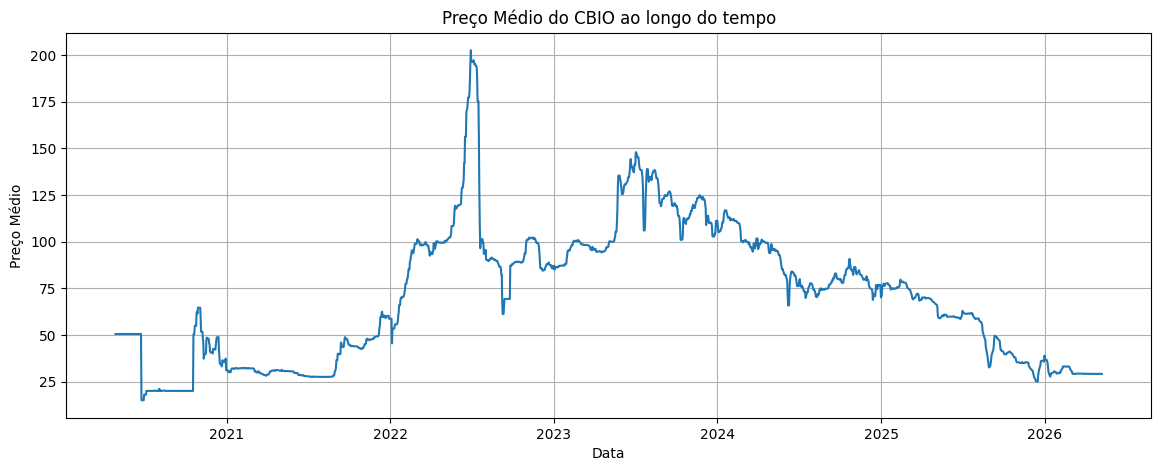

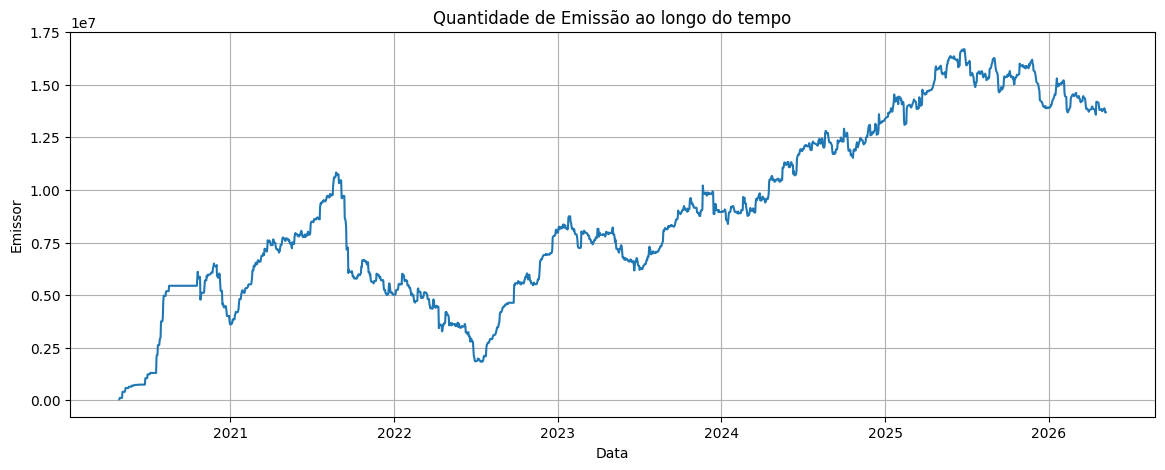

In [9]:
import matplotlib.pyplot as plt

# Plot - Preço Médio
plt.figure(figsize=(14,5))

plt.plot(
    CBIO_full['Data'],
    CBIO_full['Preço Médio']
)

plt.title('Preço Médio do CBIO ao longo do tempo')
plt.xlabel('Data')
plt.ylabel('Preço Médio')

plt.grid(True)

plt.show()


# =========================================================
# Plot - Emissor
# =========================================================

plt.figure(figsize=(14,5))
plt.plot(
    CBIO_full['Data'],
    CBIO_full['Emissor']
)
plt.title('Quantidade de Emissão ao longo do tempo')
plt.xlabel('Data')
plt.ylabel('Emissor')
plt.grid(True)
plt.show()